In [1]:
from datasets import load_dataset
import torch
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [2]:
data = load_dataset("tweet_eval", "sentiment")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
print(f"Train: {len(data['train'])} samples")
print(f"Validation: {len(data['validation'])} samples")
print(f"Test: {len(data['test'])} samples")

Train: 45615 samples
Validation: 2000 samples
Test: 12284 samples


In [5]:
print("check a tweet : ")
print(data['train'][0]['text'])
print("check its label : ")
print(data['train'][0]['label'])

print(Counter(data['train']['label']))

check a tweet : 
"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
check its label : 
2
Counter({1: 20673, 2: 17849, 0: 7093})


In [6]:
# okey , let do some analysis using pandas
train_df = pd.DataFrame(data['train'])
test_df = pd.DataFrame(data['test'])
val_df = pd.DataFrame(data['validation'])

print("=== Dataset Statistics ===")
print(f"Total tweets: {len(train_df) + len(val_df) + len(test_df)}")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Label distribution
print("\n=== Label Distribution (Train) ===")
label_counts = train_df['label'].value_counts().sort_index()
label_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
for idx, count in label_counts.items():
    print(f"{label_mapping[idx]}: {count} ({count/len(train_df)*100:.1f}%)")

# Tweet length analysis
train_df['text_length'] = train_df['text'].apply(len)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

print("\n=== Text Length Statistics ===")
print(f"Average characters: {train_df['text_length'].mean():.1f}")
print(f"Average words: {train_df['word_count'].mean():.1f}")
print(f"Max words: {train_df['word_count'].max()}")

=== Dataset Statistics ===
Total tweets: 59899
Train: 45615, Val: 2000, Test: 12284

=== Label Distribution (Train) ===
Negative: 7093 (15.5%)
Neutral: 20673 (45.3%)
Positive: 17849 (39.1%)

=== Text Length Statistics ===
Average characters: 106.9
Average words: 19.2
Max words: 35


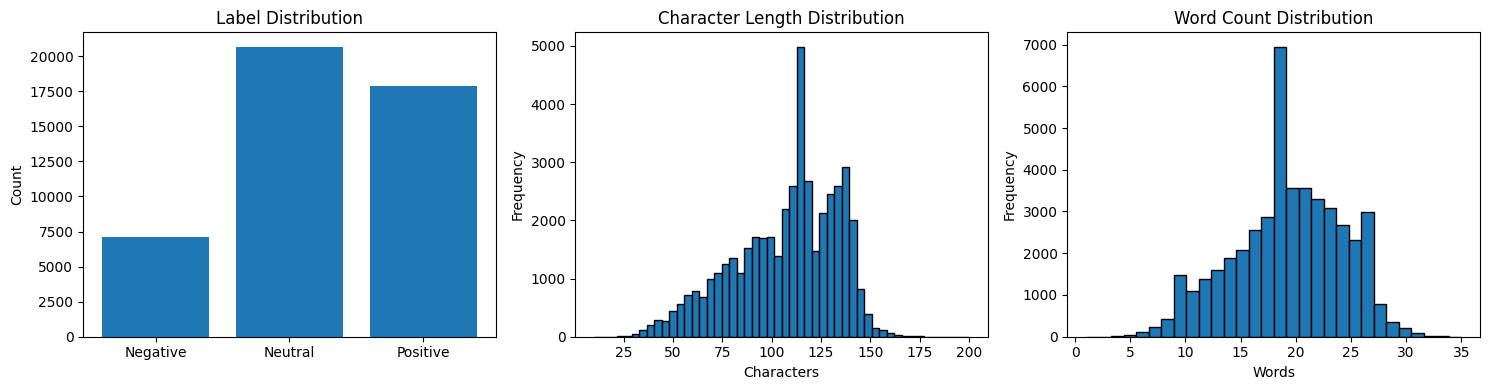

In [7]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Label distribution
axes[0].bar(label_mapping.values(), label_counts.values)
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')

# 2. Text length distribution
axes[1].hist(train_df['text_length'], bins=50, edgecolor='black')
axes[1].set_title('Character Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')

# 3. Word count distribution
axes[2].hist(train_df['word_count'], bins=30, edgecolor='black')
axes[2].set_title('Word Count Distribution')
axes[2].set_xlabel('Words')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [8]:
import re
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords


# Download NLTK resources (run once)
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
class TweetPreprocessor():
  def __init__(self):
     self.tokenizer = TweetTokenizer(
        preserve_case=False,  # lowercase
        reduce_len=True,      # shorten repeated chars (gooooood -> good)
        strip_handles=True,   # remove @mentions
     )
     self.stopwords = set(stopwords.words('english'))

  def preprocess(self, text, remove_stopwords=True):
      """
      Comprehensive tweet preprocessing
      """
      # 1. Lowercase
      text = text.lower()

      # 2. Remove URLs
      text = re.sub(r'https?://\S+|www\.\S+', '<URL>', text)

      # 3. Remove HTML tags
      text = re.sub(r'<.*?>', '', text)

      # 4. Remove mentions (optional - already handled by tokenizer if strip_handles=True)
      text = re.sub(r'@\w+', '<MENTION>', text)

      # 5. Fix repeated characters (coooool -> cool)
      text = re.sub(r'(.)\1{2,}', r'\1\1', text)

      # 6. Tokenize
      tokens = self.tokenizer.tokenize(text)

      return ' '.join(tokens)


In [10]:
# Test preprocessing
preprocessor = TweetPreprocessor()
sample_tweets = [
    "OMG this is AMAZING!!! 😍 #bestdayever https://example.com",
    "@user I'm so sad about this :( u know what i mean?",
    "RT: Check out this cool thing! #technology"
]

print("=== Preprocessing Examples ===")
for tweet in sample_tweets:
    cleaned = preprocessor.preprocess(tweet)
    print(f"Original: {tweet}")
    print(f"Cleaned:  {cleaned}\n")

=== Preprocessing Examples ===
Original: OMG this is AMAZING!!! 😍 #bestdayever https://example.com
Cleaned:  omg this is amazing ! ! 😍 #bestdayever

Original: @user I'm so sad about this :( u know what i mean?
Cleaned:  <mention> i'm so sad about this :( u know what i mean ?

Original: RT: Check out this cool thing! #technology
Cleaned:  rt : check out this cool thing ! #technology



In [11]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, word2idx=None, max_length=50):
        """
        Args:
            texts: List of preprocessed tweet texts
            labels: List of integer labels (0, 1, 2)
            word2idx: Vocabulary mapping (if None, build from data)
            max_length: Maximum sequence length (truncate longer tweets)
        """
        self.texts = texts
        self.labels = labels
        self.max_length = max_length

        # Build vocabulary if not provided
        if word2idx is None:
            self.word2idx = self._build_vocab(texts)
        else:
            self.word2idx = word2idx

        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def _build_vocab(self, texts, min_freq=2):
        """Build vocabulary from texts"""
        counter = Counter()
        for text in texts:
            tokens = text.split()
            counter.update(tokens)

        # Create vocabulary with special tokens
        vocab = ['<PAD>', '<UNK>', '<START>', '<END>']

        # Add words meeting frequency threshold
        for word, freq in counter.items():
            if freq >= min_freq:
                vocab.append(word)

        # Create mapping
        return {word: idx for idx, word in enumerate(vocab)}

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenize and convert to indices
        tokens = text.split()[:self.max_length]  # Truncate if too long
        tokens = ['<START>'] + tokens + ['<END>']  # Add special tokens

        # Convert to indices
        indices = [self.word2idx.get(token, self.word2idx['<UNK>'])
                  for token in tokens]

        return {
            'text': text,
            'indices': torch.tensor(indices, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long),
            'length': len(indices)
        }

def collate_fn(batch):
    """
    Custom collate function to pad sequences to same length
    """
    texts = [item['text'] for item in batch]
    indices = [item['indices'] for item in batch]
    labels = torch.stack([item['label'] for item in batch])
    lengths = torch.tensor([item['length'] for item in batch])

    # Pad sequences
    padded_indices = pad_sequence(
        indices,
        batch_first=True,
        padding_value=0  # <PAD> token index
    )

    return {
        'texts': texts,
        'indices': padded_indices,
        'labels': labels,
        'lengths': lengths
    }

In [12]:
preprocessor = TweetPreprocessor()

train_df['preprocessed_text'] = train_df['text'].apply(preprocessor.preprocess)
val_df['preprocessed_text'] = val_df['text'].apply(preprocessor.preprocess)
test_df['preprocessed_text'] = test_df['text'].apply(preprocessor.preprocess)

print("Preprocessing complete for all datasets.")
print(f"Example preprocessed text: {train_df['preprocessed_text'].iloc[0]}")

Preprocessing complete for all datasets.
Example preprocessed text: " qt <mention> in the original draft of the 7th book , remus lupin survived the battle of hogwarts . #happybirthdayremuslupin "


In [13]:
# Create Dataset objects
train_dataset = TweetDataset(train_df['preprocessed_text'].tolist(), train_df['label'].tolist())
val_dataset = TweetDataset(val_df['preprocessed_text'].tolist(), val_df['label'].tolist(), word2idx=train_dataset.word2idx)
test_dataset = TweetDataset(test_df['preprocessed_text'].tolist(), test_df['label'].tolist(), word2idx=train_dataset.word2idx)

print(f"Vocabulary size: {len(train_dataset.word2idx)}")

# Create DataLoader objects
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

# Example of a batch
for batch in train_loader:
    print("\nExample batch from train_loader:")
    print(f"  Texts (first 2): {batch['texts'][:2]}")
    print(f"  Indices shape: {batch['indices'].shape}")
    print(f"  Labels shape: {batch['labels'].shape}")
    print(f"  Lengths shape: {batch['lengths'].shape}")
    break

Vocabulary size: 20745
Number of training batches: 1426
Number of validation batches: 63
Number of test batches: 384

Example batch from train_loader:
  Texts (first 2): ['#rawcl monday night run with seth rollins', 'moving to covina in december things are looking up rite about now ! :)']
  Indices shape: torch.Size([32, 36])
  Labels shape: torch.Size([32])
  Lengths shape: torch.Size([32])
